In [1]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.model_selection import KFold
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
np.random.seed(12345)


# ------------------------
# Carga de datos
# ------------------------
df = pd.read_stata("data/MASTER_MICS_FINAL.dta", convert_categoricals=False)

In [2]:
# Outcomes binarios
outcomes = ["SomeRiskHome", "VeryHighRiskHome"]

# Tratamiento ANY
T_any_col = "water_treatment"   # 0/1 en tu df

# Tipo de tratamiento agrupado
T_type_col = "WQ15_g"           # 0,1,2,3,4,5,8,98...

# Controles base y extendidos
X_base = [
    "windex5",
    "helevel",
    "country_cat",
    "WS1_g",
]

X_ext_extra = [
    "Any_U5",
    "Girls_less_than15",
    "Boys_15or_less",
    "Pit_latrine",
    "Open_defecation",
    "water_carrier_edu",
]


def make_ml_frames(Y_col, use_ext=True):
    """
    Para tratamiento ANY.
    """
    cols = [Y_col, T_any_col, T_type_col] + X_base
    if use_ext:
        cols = cols + X_ext_extra

    df_ml = df[cols].dropna().copy()
    X_cols = [c for c in df_ml.columns
              if c not in [Y_col, T_any_col, T_type_col]]
    return df_ml, X_cols


def make_ml_frames_t(Y_col, T_col, use_ext=True):
    """
    Versión genérica para un tratamiento arbitrario T_col (dummy).
    """
    cols = [Y_col, T_col, T_type_col] + X_base
    if use_ext:
        cols = cols + X_ext_extra

    df_ml = df[cols].dropna().copy()
    X_cols = [c for c in df_ml.columns
              if c not in [Y_col, T_col, T_type_col]]
    return df_ml, X_cols


# DML Lineal ANY

## No heterogeneo

In [3]:
def dml_linear_constant(Y_col, use_ext=True, n_splits=5):
    df_ml, X_cols = make_ml_frames(Y_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)
    T = df_ml[T_any_col].values.reshape(-1, 1)
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)
    g_hat = np.zeros(n)
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    df_res = pd.DataFrame({"Y_res": Y_res, "T_res": T_res})
    mod_const = smf.ols("Y_res ~ T_res", data=df_res).fit(cov_type="HC1")
    
    print(f"\n===== DML LINEAL (ATE constante) ANY para {Y_col} =====")
    print(mod_const.summary())
    
    cate_const = np.full(len(df_ml), mod_const.params["T_res"])
    
    df_out = df_ml.copy()
    df_out["T_res"] = T_res
    df_out["Y_res"] = Y_res
    df_out["cate_dml_linear_const"] = cate_const
    
    return mod_const, df_out, X_cols


dml_lin_const_results_any = {}
for y in outcomes:
    mod_const, df_const, Xc = dml_linear_constant(y, use_ext=True)
    dml_lin_const_results_any[y] = {"model": mod_const, "df": df_const, "X_cols": Xc}



===== DML LINEAL (ATE constante) ANY para SomeRiskHome =====
                            OLS Regression Results                            
Dep. Variable:                  Y_res   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     160.0
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.26e-36
Time:                        11:26:19   Log-Likelihood:                -22561.
No. Observations:               55512   AIC:                         4.513e+04
Df Residuals:                   55510   BIC:                         4.514e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

## DML Lineal Hetero

In [4]:
def dml_linear_hetero(Y_col, use_ext=True, n_splits=5):
    df_ml, X_cols = make_ml_frames(Y_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)
    T = df_ml[T_any_col].values.reshape(-1, 1)
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)
    g_hat = np.zeros(n)
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    df_dml = pd.DataFrame({
        "Y_res": Y_res,
        "T_res": T_res,
    })
    for j, col in enumerate(X_cols):
        df_dml[col] = X[:, j]
    
    formula = (
        "Y_res ~ T_res"
        " + windex5"
        " + C(helevel)"
        " + C(country_cat)"
        " + C(WS1_g)"
        " + Any_U5 + Girls_less_than15 + Boys_15or_less"
        " + Pit_latrine + Open_defecation + water_carrier_edu"
        " + T_res:windex5"
        " + T_res:C(helevel)"
        " + T_res:C(country_cat)"
        " + T_res:C(WS1_g)"
        " + T_res:Any_U5 + T_res:Girls_less_than15 + T_res:Boys_15or_less"
        " + T_res:Pit_latrine + T_res:Open_defecation + T_res:water_carrier_edu"
    )
    
    mod_hetero = smf.ols(formula=formula, data=df_dml).fit(cov_type="HC1")
    
    print(f"\n===== DML LINEAL HETERO ANY para {Y_col} =====")
    print(mod_hetero.summary())
    
    df_t1 = df_dml.copy()
    df_t1["T_res"] = 1.0
    y_hat_1 = mod_hetero.predict(df_t1)
    
    df_t0 = df_dml.copy()
    df_t0["T_res"] = 0.0
    y_hat_0 = mod_hetero.predict(df_t0)
    
    cate_lin_hetero = y_hat_1 - y_hat_0
    df_dml["cate_dml_linear_hetero"] = cate_lin_hetero
    
    return mod_hetero, df_dml, X_cols


dml_lin_hetero_results_any = {}
for y in outcomes:
    mod_hetero, df_hetero, Xh = dml_linear_hetero(y, use_ext=True)
    dml_lin_hetero_results_any[y] = {"model": mod_hetero, "df": df_hetero, "X_cols": Xh}



===== DML LINEAL HETERO ANY para SomeRiskHome =====
                            OLS Regression Results                            
Dep. Variable:                  Y_res   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     7.361
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           4.13e-77
Time:                        11:26:21   Log-Likelihood:                -22368.
No. Observations:               55512   AIC:                         4.490e+04
Df Residuals:                   55432   BIC:                         4.561e+04
Df Model:                          79                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

# DML No parametrico ANY

In [5]:
def dml_nonparam_weight_trick(Y_col, use_ext=True, n_splits=5):
    df_ml, X_cols = make_ml_frames(Y_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)
    T = df_ml[T_any_col].values.reshape(-1, 1)
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)
    g_hat = np.zeros(n)
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    eps = 1e-6
    w = T_res**2
    y_star = Y_res / np.clip(T_res, eps, None) - 1.0
    
    tau_model = LGBMRegressor(max_depth=3, n_estimators=400, verbose=-1)
    tau_model.fit(X, y_star, sample_weight=w)
    
    cate_tau = tau_model.predict(X)
    
    out = df_ml.copy()
    out["T_res"] = T_res
    out["Y_res"] = Y_res
    out["w_causal"] = w
    out["y_star"] = y_star
    out["cate_dml_nonparam"] = cate_tau
    
    return out, tau_model, X_cols


dml_np_results_any = {}
for y in outcomes:
    print(f"\n=== DML NO PARAM (ANY) para {y} ===")
    out_df, tau_model, Xn = dml_nonparam_weight_trick(y, use_ext=True)
    dml_np_results_any[y] = {"df": out_df, "model": tau_model, "X_cols": Xn}



=== DML NO PARAM (ANY) para SomeRiskHome ===

=== DML NO PARAM (ANY) para VeryHighRiskHome ===


# Diferent treatments

In [6]:
# 0 = Nothing, 1 = Boil, 2 = Chlorine/AquatabsPUR, 3 = Strain/Settle, etc.
df["T_boil"]     = (df[T_type_col] == 1).astype(int)
df["T_chlorine"] = (df[T_type_col] == 2).astype(int)
df["T_strain"]   = (df[T_type_col] == 3).astype(int)
df["T_other"]    = (df[T_type_col] == 98).astype(int)

treat_defs = {
    "boil":     ("T_boil", 1),
    "chlorine": ("T_chlorine", 2),
    "strain":   ("T_strain", 3),
    "other":    ("T_other", 98),
}


# DML Lineal Dif Treatment

In [7]:
def dml_linear_constant_t(Y_col, T_col, use_ext=True, n_splits=5):
    df_ml, X_cols = make_ml_frames_t(Y_col, T_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)
    T = df_ml[T_col].values.reshape(-1, 1)
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)
    g_hat = np.zeros(n)
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    df_res = pd.DataFrame({"Y_res": Y_res, "T_res": T_res})
    mod_const = smf.ols("Y_res ~ T_res", data=df_res).fit(cov_type="HC1")
    
    print(f"\n===== DML LINEAL CONST para {Y_col}, T = {T_col} =====")
    print(mod_const.summary())
    
    cate_const = np.full(len(df_ml), mod_const.params["T_res"])
    
    df_out = df_ml.copy()
    df_out["T_res"] = T_res
    df_out["Y_res"] = Y_res
    df_out[T_col] = T.ravel()  # conservar dummy original
    df_out["cate_dml_linear_const"] = cate_const
    
    return mod_const, df_out, X_cols


In [8]:
results_by_treat_const = {}

for name, (T_col, code_val) in treat_defs.items():
    results_by_treat_const[name] = {}
    
    mask = df[T_type_col].isin([0, code_val])
    df_sub = df.loc[mask].copy()
    
    df_backup = df
    df = df_sub  # para que make_ml_frames_t use la submuestra
    
    for y in outcomes:
        print(f"\n=== DML CONST para {y}, método {name} vs nada ===")
        mod, df_const, Xc = dml_linear_constant_t(y, T_col, use_ext=True)
        results_by_treat_const[name][y] = {
            "model": mod,
            "df": df_const,
            "X_cols": Xc,
            "T_col": T_col,
        }
    
    df = df_backup



=== DML CONST para SomeRiskHome, método boil vs nada ===

===== DML LINEAL CONST para SomeRiskHome, T = T_boil =====
                            OLS Regression Results                            
Dep. Variable:                  Y_res   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     187.6
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.26e-42
Time:                        11:26:27   Log-Likelihood:                -19455.
No. Observations:               49344   AIC:                         3.891e+04
Df Residuals:                   49342   BIC:                         3.893e+04
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------

# Lineal Hetero Dif Treatment

In [9]:
def dml_linear_hetero_t(Y_col, T_col, use_ext=True, n_splits=5):
    """
    DML lineal heterogéneo para un tratamiento T_col (dummy 0/1),
    sobre la submuestra método vs nada.
    """
    df_ml, X_cols = make_ml_frames_t(Y_col, T_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)
    T = df_ml[T_col].values.reshape(-1, 1)
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)
    g_hat = np.zeros(n)
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    df_dml = pd.DataFrame({
        "Y_res": Y_res,
        "T_res": T_res,
    })
    for j, col in enumerate(X_cols):
        df_dml[col] = X[:, j]
    
    formula = (
        "Y_res ~ T_res"
        " + windex5"
        " + C(helevel)"
        " + C(country_cat)"
        " + C(WS1_g)"
        " + Any_U5 + Girls_less_than15 + Boys_15or_less"
        " + Pit_latrine + Open_defecation + water_carrier_edu"
        " + T_res:windex5"
        " + T_res:C(helevel)"
        " + T_res:C(country_cat)"
        " + T_res:C(WS1_g)"
        " + T_res:Any_U5 + T_res:Girls_less_than15 + T_res:Boys_15or_less"
        " + T_res:Pit_latrine + T_res:Open_defecation + T_res:water_carrier_edu"
    )
    
    mod_hetero = smf.ols(formula=formula, data=df_dml).fit(cov_type="HC1")
    
    print(f"\n===== DML LINEAL HETERO para {Y_col}, T = {T_col} =====")
    print(mod_hetero.summary())
    
    df_t1 = df_dml.copy()
    df_t1["T_res"] = 1.0
    y_hat_1 = mod_hetero.predict(df_t1)
    
    df_t0 = df_dml.copy()
    df_t0["T_res"] = 0.0
    y_hat_0 = mod_hetero.predict(df_t0)
    
    cate_lin_hetero = y_hat_1 - y_hat_0
    
    df_out = df_ml.copy()
    df_out["T_res"] = T_res
    df_out["Y_res"] = Y_res
    df_out[T_col] = T.ravel()  # conservar dummy original
    df_out["cate_dml_linear_hetero"] = cate_lin_hetero.values
    
    return mod_hetero, df_out, X_cols


In [10]:
results_by_treat_hetero = {}

for name, (T_col, code_val) in treat_defs.items():
    results_by_treat_hetero[name] = {}
    
    mask = df[T_type_col].isin([0, code_val])
    df_sub = df.loc[mask].copy()
    
    df_backup = df
    df = df_sub
    
    for y in outcomes:
        print(f"\n=== DML HETERO para {y}, método {name} vs nada ===")
        mod, df_het, Xh = dml_linear_hetero_t(y, T_col, use_ext=True)
        results_by_treat_hetero[name][y] = {
            "model": mod,
            "df": df_het,
            "X_cols": Xh,
            "T_col": T_col,
        }
    
    df = df_backup



=== DML HETERO para SomeRiskHome, método boil vs nada ===

===== DML LINEAL HETERO para SomeRiskHome, T = T_boil =====
                            OLS Regression Results                            
Dep. Variable:                  Y_res   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     6.626
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.56e-66
Time:                        11:26:36   Log-Likelihood:                -19313.
No. Observations:               49344   AIC:                         3.879e+04
Df Residuals:                   49264   BIC:                         3.949e+04
Df Model:                          79                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      

# DML No parametrico Dif Treatment

In [11]:
def dml_nonparam_weight_trick_t(Y_col, T_col, use_ext=True, n_splits=5):
    """
    DML no paramétrico (R-learner / weight trick) para T_col (dummy 0/1),
    en la submuestra método vs nada.
    """
    df_ml, X_cols = make_ml_frames_t(Y_col, T_col, use_ext=use_ext)
    
    Y = df_ml[Y_col].values.reshape(-1, 1)
    T = df_ml[T_col].values.reshape(-1, 1)
    X = df_ml[X_cols].values
    n = Y.shape[0]
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=12345)
    m_hat = np.zeros(n)
    g_hat = np.zeros(n)
    
    for tr, te in kf.split(X):
        X_tr, X_te = X[tr], X[te]
        T_tr, Y_tr = T[tr].ravel(), Y[tr].ravel()
        
        m_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        m_model.fit(X_tr, T_tr)
        m_hat[te] = m_model.predict_proba(X_te)[:, 1]
        
        g_model = LGBMClassifier(max_depth=3, n_estimators=200, verbose=-1)
        g_model.fit(X_tr, Y_tr)
        g_hat[te] = g_model.predict_proba(X_te)[:, 1]
    
    T_res = T.ravel() - m_hat
    Y_res = Y.ravel() - g_hat
    
    eps = 1e-6
    w = T_res**2
    y_star = Y_res / np.clip(T_res, eps, None) - 1.0
    
    tau_model = LGBMRegressor(max_depth=3, n_estimators=400, verbose=-1)
    tau_model.fit(X, y_star, sample_weight=w)
    
    cate_tau = tau_model.predict(X)
    
    out = df_ml.copy()
    out["T_res"] = T_res
    out["Y_res"] = Y_res
    out["w_causal"] = w
    out["y_star"] = y_star
    out["cate_dml_nonparam"] = cate_tau
    out[T_col] = T.ravel()  # conservar dummy original
    
    return out, tau_model, X_cols


In [12]:
results_by_treat_np = {}

for name, (T_col, code_val) in treat_defs.items():
    results_by_treat_np[name] = {}
    
    mask = df[T_type_col].isin([0, code_val])
    df_sub = df.loc[mask].copy()
    
    df_backup = df
    df = df_sub
    
    for y in outcomes:
        print(f"\n=== DML NO PARAM para {y}, método {name} vs nada ===")
        out_df, tau_model, Xn = dml_nonparam_weight_trick_t(y, T_col, use_ext=True)
        results_by_treat_np[name][y] = {
            "df": out_df,
            "model": tau_model,
            "X_cols": Xn,
            "T_col": T_col,
        }
    
    df = df_backup



=== DML NO PARAM para SomeRiskHome, método boil vs nada ===

=== DML NO PARAM para VeryHighRiskHome, método boil vs nada ===

=== DML NO PARAM para SomeRiskHome, método chlorine vs nada ===

=== DML NO PARAM para VeryHighRiskHome, método chlorine vs nada ===

=== DML NO PARAM para SomeRiskHome, método strain vs nada ===

=== DML NO PARAM para VeryHighRiskHome, método strain vs nada ===

=== DML NO PARAM para SomeRiskHome, método other vs nada ===

=== DML NO PARAM para VeryHighRiskHome, método other vs nada ===


# Qini

In [13]:
def qini_gain_facure(y, t, cate, n_points=50):
    order = np.argsort(-cate)
    y = y[order]
    t = t[order]

    n = len(y)
    treated = (t == 1)

    indices = (np.linspace(1, n, n_points)).astype(int) - 1
    fracs = []
    gains = []
    cum_y_t = cum_y_c = 0.0
    cum_t = cum_c = 0

    idx_set = set(indices.tolist())
    for idx in range(n):
        if treated[idx]:
            cum_y_t += y[idx]
            cum_t += 1
        else:
            cum_y_c += y[idx]
            cum_c += 1

        if idx in idx_set:
            k = idx + 1
            frac = k / n
            fracs.append(frac)
            if cum_t > 0 and cum_c > 0:
                ate = (cum_y_t / cum_t) - (cum_y_c / cum_c)
                gain = k * ate
            else:
                gain = 0.0
            gains.append(gain)

    return np.array(fracs), np.array(gains)


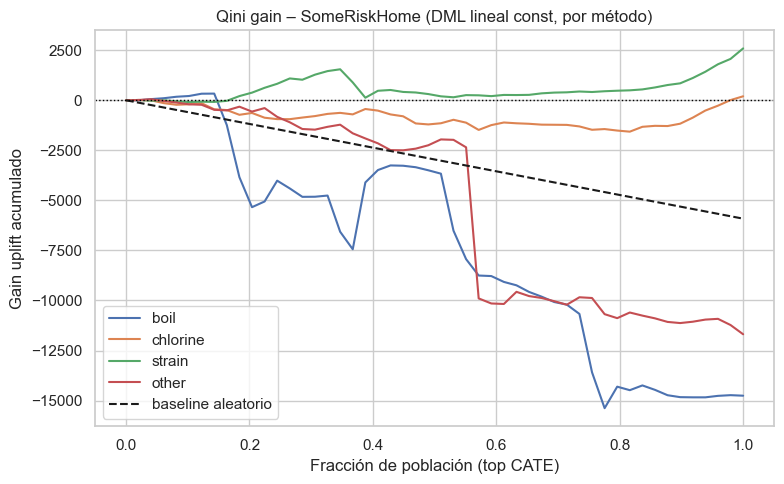

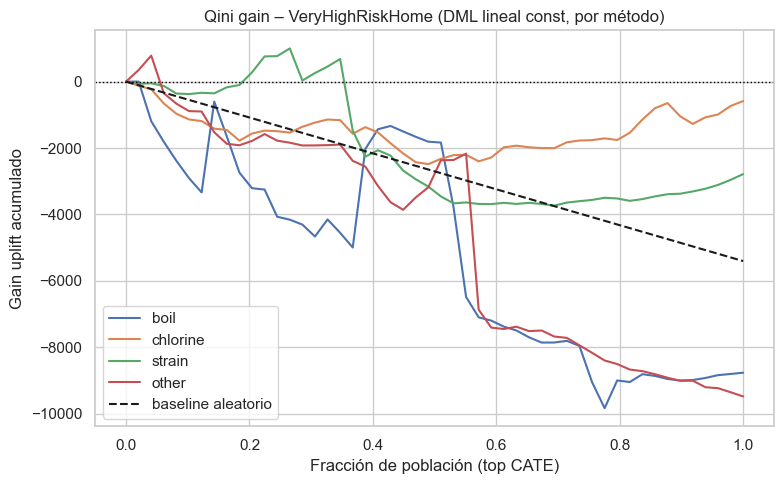

In [17]:
def plot_qini_by_method_linear_const(Y_col, n_points=50):
    plt.figure(figsize=(8, 5))
    last_gains = []

    for name, info in treat_defs.items():
        T_col, code_val = info
        
        df_const = results_by_treat_const[name][Y_col]["df"]
        t = df_const[T_col].values.astype(int)
        y = df_const[Y_col].values.astype(float)
        cate = df_const["cate_dml_linear_const"].values.astype(float)
        
        fracs, gains = qini_gain_facure(y, t, cate, n_points=n_points)
        plt.plot(fracs, gains, label=f"{name}")
        last_gains.append(gains[-1])

    # baseline aleatorio (recta 0 -> gain_final_promedio)
    gain_final = np.mean(last_gains)
    plt.plot([0, 1], [0, gain_final], "k--", label="baseline aleatorio")
    
    plt.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.title(f"Qini gain – {Y_col} (DML lineal const, por método)")
    plt.xlabel("Fracción de población (top CATE)")
    plt.ylabel("Gain uplift acumulado")
    plt.legend()
    plt.tight_layout()
    plt.show()

for y in outcomes:
    plot_qini_by_method_linear_const(y, n_points=50)


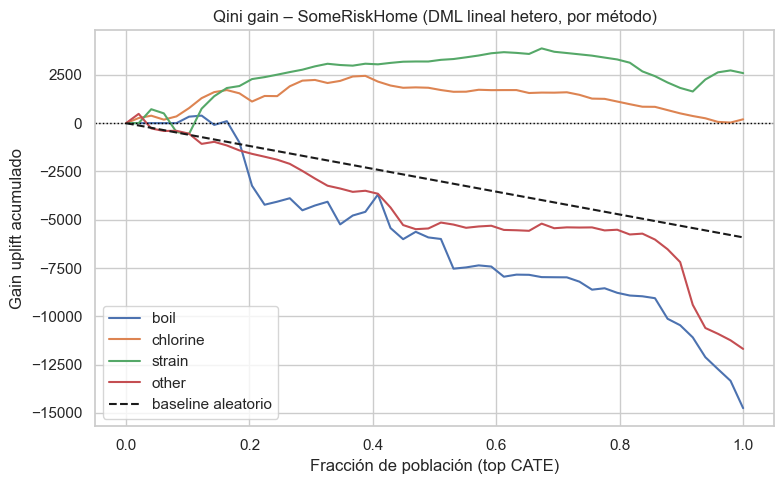

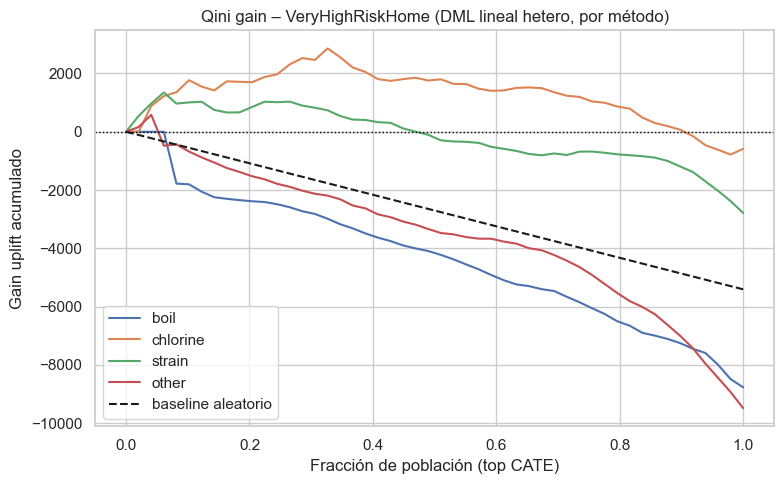

In [14]:
def plot_qini_by_method_linear_hetero(Y_col, n_points=50):
    plt.figure(figsize=(8, 5))
    last_gains = []

    for name, info in treat_defs.items():
        T_col, code_val = info
        
        df_het = results_by_treat_hetero[name][Y_col]["df"]
        t = df_het[T_col].values.astype(int)
        y = df_het[Y_col].values.astype(float)
        cate = df_het["cate_dml_linear_hetero"].values.astype(float)
        
        fracs, gains = qini_gain_facure(y, t, cate, n_points=n_points)
        plt.plot(fracs, gains, label=f"{name}")
        last_gains.append(gains[-1])

    # baseline random: recta desde (0,0) hasta (1, gain_final_promedio)
    gain_final = np.mean(last_gains)
    plt.plot([0, 1], [0, gain_final], "k--", label="baseline aleatorio")
    
    plt.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.title(f"Qini gain – {Y_col} (DML lineal hetero, por método)")
    plt.xlabel("Fracción de población (top CATE)")
    plt.ylabel("Gain uplift acumulado")
    plt.legend()
    plt.tight_layout()
    plt.show()


for y in outcomes:
    plot_qini_by_method_linear_hetero(y, n_points=50)


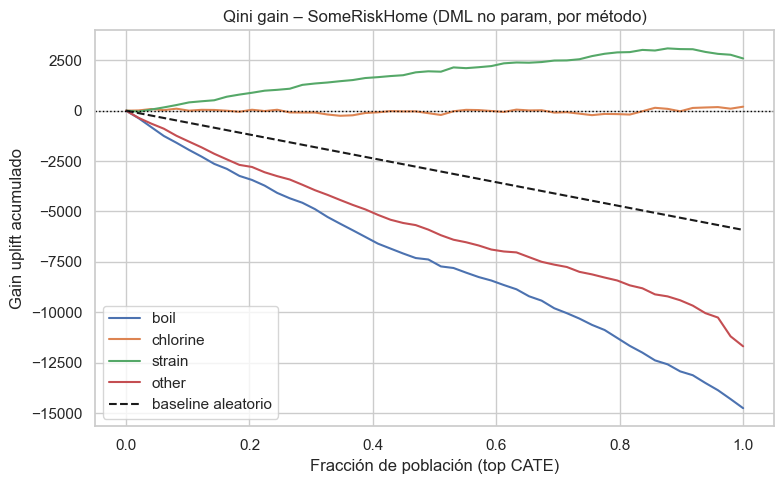

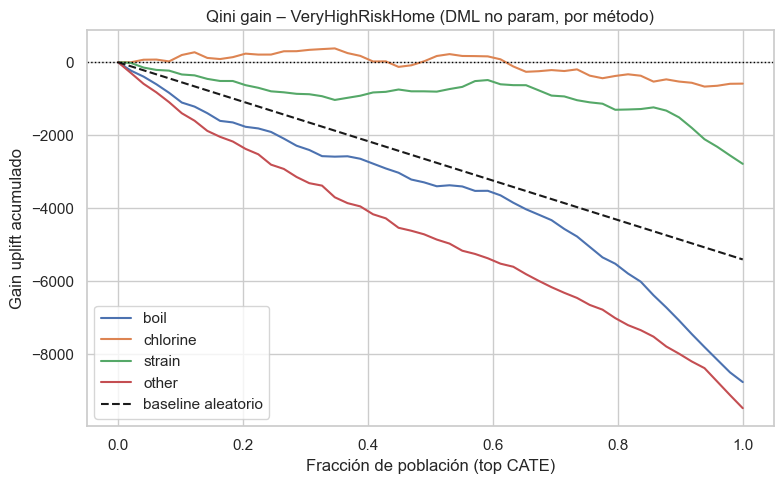

In [15]:
def plot_qini_by_method_nonparam(Y_col, n_points=50):
    plt.figure(figsize=(8, 5))
    last_gains = []

    for name, info in treat_defs.items():
        T_col, code_val = info
        
        df_np = results_by_treat_np[name][Y_col]["df"]
        t = df_np[T_col].values.astype(int)
        y = df_np[Y_col].values.astype(float)
        cate = df_np["cate_dml_nonparam"].values.astype(float)
        
        fracs, gains = qini_gain_facure(y, t, cate, n_points=n_points)
        plt.plot(fracs, gains, label=f"{name}")
        last_gains.append(gains[-1])

    gain_final = np.mean(last_gains)
    plt.plot([0, 1], [0, gain_final], "k--", label="baseline aleatorio")
    
    plt.axhline(0, color="black", linestyle=":", linewidth=1)
    plt.title(f"Qini gain – {Y_col} (DML no param, por método)")
    plt.xlabel("Fracción de población (top CATE)")
    plt.ylabel("Gain uplift acumulado")
    plt.legend()
    plt.tight_layout()
    plt.show()


for y in outcomes:
    plot_qini_by_method_nonparam(y, n_points=50)
